
# **Forecasting BankNifty Realized Volatility: Evidence from an Emerging Market**

In [1]:
# Importing required Libraries
import os, glob, fnmatch, warnings
from collections import defaultdict
from dataclasses import dataclass, field
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import gamma as gamma_fn
import statsmodels.api as sm
from IPython.display import display
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from arch import arch_model
warnings.filterwarnings("ignore")
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

SESSION_START, SESSION_END = "09:15", "15:30"
BARS_PER_DAY      = 75         
MIN_BARS_PER_DAY  = 20          
DAYFIRST_DATES    = True        
TRADING_DAYS_PER_YEAR = 252
HORIZONS         = [1, 5, 22]   # daily / weekly / monthly
PRIMARY_HORIZON  = 1
OOS_FRACTION     = 0.30        
JUMP_ALPHA       = 0.999        
MS_REFIT_EVERY    = 21          
GARCH_REFIT_EVERY = 5   
MS_SCALE          = 1e4          
PRED_FLOOR_FRAC   = 0.05      
ALPHA_FDR    = 0.10
ALPHA_MCS    = 0.10
ALPHA_TEST   = 0.05
ALPHA_PARENT = 0.10
TOP_N        = 3
VAR_TAU      = 0.05
MCS_SEED     = 20240101
REGIME_Q     = 2 / 3
REGIME_MIN   = 250
MIN_REGIME_N = 120

### Step 1: Preprocessing of Data

In [2]:
# Data Loading and cleaning
DATA_DIR = "Datasets"
BANKNIFTY_PATTERNS = ["NIFTY FMCG_5minute.csv"]
VIX_PATTERNS   = ["INDIA VIX_5minute.csv"]

def find_data_file(patterns, data_dir=DATA_DIR):
    files = [p for p in glob.glob(os.path.join(data_dir, "*")) if os.path.isfile(p)]
    for pat in patterns:
        hits = [p for p in files if fnmatch.fnmatch(os.path.basename(p).lower(), pat.lower())]
        if hits:
            return sorted(hits)[0]
    return None

def parse_datetime_column(s, dayfirst=DAYFIRST_DATES):
    out = pd.to_datetime(s, dayfirst=dayfirst, errors="coerce")
    if out.isna().any():
        for fmt in ("%d-%m-%Y %H:%M", "%d-%m-%Y %H:%M:%S","%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M"):
            trial = pd.to_datetime(s, format=fmt, errors="coerce")
            if trial.notna().sum() > out.notna().sum():
                out = trial
    return out

def load_intraday_csv(path, session_filter=True):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    dt_col = next((c for c in df.columns if c in ("datetime", "timestamp", "date_time", "date", "time")), None)
    if dt_col is None:
        raise ValueError(f"{path}: no datetime-like column found. Columns = {list(df.columns)}")
    df["datetime"] = parse_datetime_column(df[dt_col])
    df = df.rename(columns={"o": "open", "h": "high", "l": "low", "c": "close", "v": "volume"})
    keep = ["datetime", "open", "high", "low", "close", "volume"]
    df = df[[c for c in keep if c in df.columns]]
    df = df.dropna(subset=["datetime", "close"]).sort_values("datetime").reset_index(drop=True)

    if session_filter:
        t = df["datetime"].dt.time
        in_session = ((t >= pd.Timestamp(SESSION_START).time()) & (t <= pd.Timestamp(SESSION_END).time()))
        df = df[in_session].copy()
    df["date"] = df["datetime"].dt.normalize()
    counts = df.groupby("date")["close"].transform("size")
    df = df[counts >= MIN_BARS_PER_DAY].reset_index(drop=True)
    return df

BANKNIFTY_PATH = find_data_file(BANKNIFTY_PATTERNS)
VIX_PATH   = find_data_file(VIX_PATTERNS)
nifty_raw = load_intraday_csv(BANKNIFTY_PATH)
vix_raw   = load_intraday_csv(VIX_PATH)

# Data Quality Checks
def data_quality_report(path, label):
    raw = pd.read_csv(path)
    raw.columns = [c.strip().lower() for c in raw.columns]
    dt_col = next(c for c in raw.columns if c in ("datetime", "timestamp", "date_time", "date", "time"))
    good = parse_datetime_column(raw[dt_col])         
    default = pd.to_datetime(raw[dt_col], errors="coerce")  
    n_diff  = int((good != default).sum())

    tmp = pd.DataFrame({"dt": good, "close": raw["close"]}).dropna()
    tmp["d"] = tmp["dt"].dt.normalize()
    t = tmp["dt"].dt.time
    in_sess = ((t >= pd.Timestamp(SESSION_START).time()) & (t <= pd.Timestamp(SESSION_END).time()))
    bars_per_day = tmp.groupby("d").size()
    r = tmp.assign(lc=np.log(tmp["close"])).groupby("d")["lc"].diff().dropna()

    print(f"--- {label} ---")
    print(f"rows: {len(raw):,}")
    print(f"timestamps strictly increasing: {good.is_monotonic_increasing}")
    print(f"bars outside {SESSION_START}-{SESSION_END}: {int((~in_sess).sum()):,}"
          f"on {tmp.loc[~in_sess, 'd'].nunique()} days")
    print(f"  days with < {MIN_BARS_PER_DAY} bars (stubs): "
          f"{int((bars_per_day < MIN_BARS_PER_DAY).sum())}")
    print(f"  exactly-zero intraday returns: {int((r == 0).sum()):,} "
          f"({100*(r == 0).mean():.2f}%)")
    print()

data_quality_report(BANKNIFTY_PATH, "BANKNIFTY")
data_quality_report(VIX_PATH,   "INDIA VIX")

--- BANKNIFTY ---
rows: 209,803
timestamps strictly increasing: True
bars outside 09:15-15:30: 143on 11 days
  days with < 20 bars (stubs): 12
  exactly-zero intraday returns: 281 (0.14%)

--- INDIA VIX ---
rows: 209,734
timestamps strictly increasing: True
bars outside 09:15-15:30: 140on 11 days
  days with < 20 bars (stubs): 12
  exactly-zero intraday returns: 18,341 (8.86%)



#### Step 2: Realized Feature formation

In [3]:
MU1= np.sqrt(2 / np.pi)
MU_4_3 = 2 ** (2 / 3) * gamma_fn(7 / 6) / gamma_fn(1 / 2)
JUMP_Z_CRIT = stats.norm.ppf(JUMP_ALPHA)

def realized_measures_from_returns(r):
    r = np.asarray(r, dtype=float)
    M = len(r)
    if M < 5:
        return None
    RV = float(np.sum(r ** 2))
    BV = float(MU1 ** (-2) * (M / (M - 1)) * np.sum(np.abs(r[1:]) * np.abs(r[:-1])))
    RQ = float((M / 3) * np.sum(r ** 4))
    TQ = float(M * MU_4_3 ** (-3) * (M / (M - 2)) * np.sum( (np.abs(r[2:]) ** (4/3)) * (np.abs(r[1:-1]) ** (4/3)) * (np.abs(r[:-2]) ** (4/3)))) if M > 2 else np.nan
    RS_plus  = float(np.sum(r[r > 0] ** 2))
    RS_minus = float(np.sum(r[r < 0] ** 2))
    rel_jump = (RV - BV) / RV if RV > 0 else 0.0
    denom = np.sqrt(max(0.6090 * max(TQ / BV ** 2, 1.0) / M, 1e-16)) if BV > 0 else np.nan
    Z = rel_jump / denom if denom and np.isfinite(denom) and denom > 0 else 0.0
    J = max(RV - BV, 0.0) if Z > JUMP_Z_CRIT else 0.0
    C = RV - J
    return dict(RV=RV, BV=BV, RQ=RQ, TQ=TQ, RS_plus=RS_plus, RS_minus=RS_minus, J=J, C=C, Z=Z, n_bars=M)

def build_daily_realized_table(intraday_df):
    df = intraday_df.copy()
    df["log_close"] = np.log(df["close"])
    df["log_open"]  = np.log(df["open"])
    df["ret"] = df.groupby("date")["log_close"].diff()
    _first = df.groupby("date").cumcount() == 0
    df.loc[_first, "ret"] = df.loc[_first, "log_close"] - df.loc[_first, "log_open"]
    df = df.dropna(subset=["ret"])

    recs = []
    for d, g in df.groupby("date"):
        m = realized_measures_from_returns(g["ret"].values)
        if m is not None:
            m["date"]  = d
            m["close"] = float(g["close"].iloc[-1])
            m["open"]  = float(g["open"].iloc[0])
            recs.append(m)
    out = pd.DataFrame(recs).set_index("date").sort_index()
    return out

rv_table = build_daily_realized_table(nifty_raw)
vix_daily = vix_raw.groupby("date")["close"].last()
rv_table["VIX_close"] = vix_daily.reindex(rv_table.index)
rv_table["IV"] = (rv_table["VIX_close"] / 100) ** 2 / TRADING_DAYS_PER_YEAR
rv_table = rv_table.dropna(subset=["RV", "IV"])
rv_table = rv_table[rv_table["RV"] > 0]
_dbg = nifty_raw.copy()
_dbg["lc"] = np.log(_dbg["close"]); _dbg["lo"] = np.log(_dbg["open"])
_cmp = []
for _dt, _g in _dbg.groupby("date"):
    _lc = _g["lc"].values; _lo = _g["lo"].values
    if len(_lc) < 5:
        continue
    _rw = np.diff(_lc)
    _cmp.append((float((_rw ** 2).sum()),float((_rw ** 2).sum() + (_lc[0] - _lo[0]) ** 2),float(_lc[-1] - _lo[0])))
_cmp = pd.DataFrame(_cmp, columns=["RV_excl_first", "RV_incl_first", "r_oc"])
_cmp = _cmp[(_cmp["RV_excl_first"] > 0) & (_cmp["RV_incl_first"] > 0)]
print(f"  variance share carried by the first bar : "
      f"{100*(_cmp['r_oc']*0 + (_cmp['RV_incl_first']-_cmp['RV_excl_first'])).mean()/_cmp['RV_incl_first'].mean():.1f}%")
print(f"  RV level, included / excluded           : "
      f"{_cmp['RV_incl_first'].mean()/_cmp['RV_excl_first'].mean():.4f}")
for _nm, _c in (("excluded (common convention)", "RV_excl_first"),("INCLUDED (used here) ", "RV_incl_first")):
    _z = _cmp["r_oc"] / np.sqrt(_cmp[_c])

ann_rv = np.sqrt(rv_table["RV"] * TRADING_DAYS_PER_YEAR) * 100
print(f"Daily realized-measures table: {len(rv_table):,} trading days\n")
print("Annualised realized volatility (%):")
print(ann_rv.describe(percentiles=[.01, .25, .5, .75, .99]).round(2).to_string())
print(f"\nMean India VIX               : {rv_table['VIX_close'].mean():.2f}")
print(f"Mean annualised INTRADAY RV  : {ann_rv.mean():.2f}")
print(f"VIX - intraday RV            : {rv_table['VIX_close'].mean() - ann_rv.mean():+.2f} vol points")
print(f"Corr(annualised RV, VIX)     : {np.corrcoef(ann_rv, rv_table['VIX_close'])[0,1]:.3f}")
print(f"\nDays flagged as containing a significant jump: " f"{(rv_table['J'] > 0).sum():,} ({100*(rv_table['J'] > 0).mean():.1f}%)")
print("\nTop 8 realized-volatility days (annualised %) - check these are real market events:")
print(ann_rv.sort_values(ascending=False).head(8).round(1).to_string())

  variance share carried by the first bar : 17.6%
  RV level, included / excluded           : 1.2129
Daily realized-measures table: 2,795 trading days

Annualised realized volatility (%):
count    2795.00
mean       12.81
std         6.39
min         1.99
1%          5.96
25%         9.38
50%        11.59
75%        14.44
99%        37.42
max       142.03

Mean India VIX               : 16.66
Mean annualised INTRADAY RV  : 12.81
VIX - intraday RV            : +3.85 vol points
Corr(annualised RV, VIX)     : 0.545

Days flagged as containing a significant jump: 335 (12.0%)

Top 8 realized-volatility days (annualised %) - check these are real market events:
date
2020-03-13    142.0
2015-02-28     82.4
2020-03-19     81.5
2020-03-23     72.6
2016-02-29     72.2
2020-03-20     62.8
2020-03-27     59.1
2020-03-26     53.1


## **RQ1: What does the trading-time convention discard, and what may we therefore claim?**

### Step 3: Overnight Vs Intraday Variance

In [4]:
# Overnight Decomposition
day_open  = nifty_raw.groupby("date")["open"].first()
day_close = nifty_raw.groupby("date")["close"].last()

overnight_ret = np.log(day_open) - np.log(day_close.shift(1))
rv_table["RV_overnight"] = (overnight_ret ** 2).reindex(rv_table.index)
rv_table["RV_total"] = rv_table["RV"] + rv_table["RV_overnight"]

ov = rv_table.dropna(subset=["RV_overnight"])
share = 100 * ov["RV_overnight"].sum() / ov["RV_total"].sum()

print("OVERNIGHT VARIANCE DECOMPOSITION")
print(f"  overnight share of total daily variance : {share:.1f}%")
print(f"  median overnight / total (per day)      : "
      f"{100*(ov['RV_overnight']/ov['RV_total']).median():.1f}%")
print(f"  corr(overnight, intraday)               : "
      f"{ov['RV_overnight'].corr(ov['RV']):.3f}")
print(f"  autocorr(1) of overnight variance       : {ov['RV_overnight'].autocorr(1):.3f}")
print(f"  autocorr(1) of intraday RV              : {ov['RV'].autocorr(1):.3f}")

ann_rv_intra = np.sqrt(ov["RV"] * TRADING_DAYS_PER_YEAR) * 100
ann_rv_total = np.sqrt(ov["RV_total"] * TRADING_DAYS_PER_YEAR) * 100
vrp_intra = ov["VIX_close"].mean() - ann_rv_intra.mean()
vrp_total = ov["VIX_close"].mean() - ann_rv_total.mean()
print()
print("VARIANCE RISK PREMIUM")
print(f"  mean India VIX                          : {ov['VIX_close'].mean():.2f}")
print(f"  mean annualised INTRADAY RV             : {ann_rv_intra.mean():.2f}")
print(f"  mean annualised TOTAL RV (like-for-like): {ann_rv_total.mean():.2f}")
print(f"  VIX - intraday RV (OVERSTATED)          : {vrp_intra:+.2f} vol points")
print(f"  VIX - total RV    (variance risk premium): {vrp_total:+.2f} vol points")
print(f"  units mismatch wrongly counted as premium: {vrp_intra - vrp_total:.2f} vol points")
print()


OVERNIGHT VARIANCE DECOMPOSITION
  overnight share of total daily variance : 26.8%
  median overnight / total (per day)      : 8.7%
  corr(overnight, intraday)               : 0.488
  autocorr(1) of overnight variance       : 0.169
  autocorr(1) of intraday RV              : 0.328

VARIANCE RISK PREMIUM
  mean India VIX                          : 16.66
  mean annualised INTRADAY RV             : 12.81
  mean annualised TOTAL RV (like-for-like): 14.43
  VIX - intraday RV (OVERSTATED)          : +3.85 vol points
  VIX - total RV    (variance risk premium): +2.23 vol points
  units mismatch wrongly counted as premium: 1.62 vol points



A large overnight share means the trading-time RV convention discards a substantial
part of the variance that a close-to-close risk measure would need. Overnight variance
is also typically far LESS persistent than intraday RV, which is why models built on
trading-time RV can still forecast well even though they ignore this component. ( to be verified)


## RQ2: **Must Realized Variance be modelled in logs rather than levels for Indian Equity Market to take care of concentrated variance?**

### Step 4: Levels Vs Log HAR Models

Realized variance is extremely right-skewed and
the Indian market makes this acute, a handful of event days dominate the sample. The cell below
reports the decisive diagnostic: the first-order autocorrelation of RV in levels versus in
logs. If the log autocorrelation is far higher, the series is far more predictable on a log
scale, and any levels-OLS fit is being driven by a few extreme observations rather than by the
typical day. That single comparison motivates the entire log specification family.

1. **Persistence.** If $\log RV$ is markedly more autocorrelated than $RV$, the log scale is
   where the predictable structure lives.
2. **Forecast censoring.** A levels model can produce negative variance forecasts, which must
   then be floored at a positive number. Every floor hit is a forecast the model could not
   actually make. The log specification cannot produce one by construction.


In [5]:
# Feature Construction
def add_har_lags(df, col, windows=(1, 5, 22)):
    return pd.DataFrame({f"{col}_{w}": df[col].rolling(w).mean() for w in windows},  index=df.index)

BASE_MEASURES = ["RV", "C", "J", "RQ", "TQ", "RS_plus", "RS_minus", "IV"]
feat = rv_table.copy()
for c in BASE_MEASURES:
    feat = pd.concat([feat, add_har_lags(feat, c)], axis=1)

for c in ["RV", "C", "IV"]:
    lg = np.log(feat[c].clip(lower=1e-16))
    for w in (1, 5, 22):
        feat[f"log{c}_{w}"] = lg.rolling(w).mean()

feat["ret_d"]   = np.log(feat["close"]).diff()
feat["r_pos_1"] = feat["ret_d"].clip(lower=0)
feat["r_neg_1"] = feat["ret_d"].clip(upper=0)

_ret_filled = feat["ret_d"].fillna(0.0)
for _w in (5, 22):
    feat[f"r_neg_{_w}"] = _ret_filled.clip(upper=0).rolling(_w).mean()
    feat[f"r_pos_{_w}"] = _ret_filled.clip(lower=0).rolling(_w).mean()

feat["r_over_1"]    = (np.log(day_open) - np.log(day_close.shift(1))).reindex(feat.index)
feat["r_over_1"]    = feat["r_over_1"].fillna(0.0)
feat["r_over_pos"]  = feat["r_over_1"].clip(lower=0)
feat["r_over_neg"]  = feat["r_over_1"].clip(upper=0)
feat["logRVover_1"] = np.log((feat["r_over_1"] ** 2).clip(lower=1e-16))

_lrv = np.log(feat["RV"].clip(lower=1e-16))
feat["VoV_5"]     = _lrv.rolling(5).std()
feat["VoV_22"]    = _lrv.rolling(22).std()
feat["logVoV_5"]  = np.log(feat["VoV_5"].clip(lower=1e-8))
feat["logVoV_22"] = np.log(feat["VoV_22"].clip(lower=1e-8))
feat["RQ_sqrt"] = np.sqrt(feat["RQ"])

for h in HORIZONS:
    feat[f"RV_target_h{h}"] = feat["RV"].shift(-1).rolling(h).mean().shift(-(h - 1))
    feat[f"logRV_target_h{h}"] = np.log(feat[f"RV_target_h{h}"].clip(lower=1e-16))

predictor_cols = [c for c in feat.columns if not c.startswith(("RV_target", "logRV_target"))]
feat = feat.dropna(subset=predictor_cols).copy()

def assert_specs_full_rank(feat, specs, tol=1e-8):

    bad = []
    for k, s in specs.items():
        cols = [c for c in s.regressors if c in feat.columns]
        if len(cols) < 2:
            continue
        Z = feat[cols].dropna().values.astype(float)
        Z = np.column_stack([np.ones(len(Z)), Z])          # intercept, as fitted
        r = np.linalg.matrix_rank(Z, tol=tol * max(1.0, np.abs(Z).max()))
        if r < Z.shape[1]:
            bad.append(f"{k}: rank {r} of {Z.shape[1]}")
    if bad:
        raise AssertionError("rank-deficient specification(s): " + "; ".join(bad))
    return True


print(f"Feature table: {feat.shape[0]:,} rows x {feat.shape[1]} columns")
print(f"Sample: {feat.index.min().date()} -> {feat.index.max().date()}\n")

ac_lev = feat["RV"].autocorr(1)
ac_log = np.log(feat["RV"]).autocorr(1)

print("RQ2 KEY DIAGNOSTIC - persistence in levels vs logs")
print(f"autocorr(RV, lag 1) = {ac_lev:.3f}")
print(f"autocorr(log RV, lag 1) = {ac_log:.3f}")
print(f"skewness of RV = {stats.skew(feat['RV']):.2f}")
print(f"skewness of log RV = {stats.skew(np.log(feat['RV'])):.2f}")
print(f"kurtosis of RV = {stats.kurtosis(feat['RV']):.1f}")
top5 = feat['RV'].nlargest(5).sum() / feat['RV'].sum()
print(f"  share of total sample RV from the 5 largest days = {100*top5:.1f}%")
print()
if ac_log > ac_lev + 0.10:
    print(f"log RV is MUCH more persistent ({ac_log:.3f} vs {ac_lev:.3f}).")
    

Feature table: 2,774 rows x 71 columns
Sample: 2015-02-12 -> 2026-05-18

RQ2 KEY DIAGNOSTIC - persistence in levels vs logs
autocorr(RV, lag 1) = 0.329
autocorr(log RV, lag 1) = 0.587
skewness of RV = 26.12
skewness of log RV = 0.91
kurtosis of RV = 950.9
  share of total sample RV from the 5 largest days = 7.8%

log RV is MUCH more persistent (0.587 vs 0.329).


 Level HAR are expected to give poorer results

### Step 5: Model Specifications

In [6]:
@dataclass
class ModelSpec:
    name: str
    regressors: list
    kind: str = "ols"       
    family: str = "levels" 

MODEL_SPECS = {
# Benchmark models  
 "Naive_RW":    ModelSpec("Naive / Random Walk", ["RV_1"], "naive", "benchmark"),
 "GARCH11":     ModelSpec("GARCH(1,1) [Bollerslev 1986]", [], "garch", "benchmark"),

# Levels / HAR-family models
 "HAR_RV":      ModelSpec("HAR-RV", ["RV_1","RV_5","RV_22"], "ols", "levels"),
 "HAR_CJ":      ModelSpec("HAR-CJ",["C_1","C_5","C_22","J_1","J_5","J_22"], "ols", "levels"),
 "HAR_RS":      ModelSpec("HAR-RS/SHAR",  ["RS_plus_1","RS_minus_1","RV_5","RV_22"], "ols", "levels"),
 "HARQ":        ModelSpec("HARQ",  ["RV_1","RV_5","RV_22"], "harq", "levels"),
 "HAR_RV_WLS":  ModelSpec("HAR-RV WLS",  ["RV_1","RV_5","RV_22"], "wls", "levels"),
 "HAR_CJ_IV":   ModelSpec("HAR-CJ-IV [Busch-Christensen-Nielsen 2011]", ["C_1","C_5","C_22","J_1","J_5","J_22","IV_1"], "ols", "levels"),
 "HARQ_CJ":     ModelSpec("HARQ-CJ", ["C_1","C_5","C_22","J_1","J_5","J_22"], "harqcj", "levels"),
 "MS_HAR":      ModelSpec("MS-log-HAR",  ["logRV_1","logRV_5","logRV_22"], "ms", "log"),
 "MS_HARQ_CJ":  ModelSpec("MS-log-HARQ-CJ",  ["logC_1","logC_5","logC_22","RQ_sqrt"], "msharqcj", "log"),

 # Log Models
 "logHAR_RV":   ModelSpec("log-HAR-RV", ["logRV_1","logRV_5","logRV_22"], "log", "log"),
 "logHAR_C":    ModelSpec("log-HAR-C", ["logC_1","logC_5","logC_22"], "log", "log"),
 "logHAR_RV_IV":ModelSpec("log-HAR-RV-IV", ["logRV_1","logRV_5","logRV_22","logIV_1"], "log", "log"),
 "logHAR_C_IV": ModelSpec("log-HAR-C-IV [log spec. + India VIX, continuous component]", ["logC_1","logC_5","logC_22","logIV_1"], "log", "log"),

# Log models with leverage
 "logHAR_RV_L": ModelSpec("log-HAR-RV-L", ["logRV_1","logRV_5","logRV_22","r_pos_1","r_neg_1"], "log", "log"),
 "logHAR_RV_IV_L": ModelSpec("log-HAR-RV-IV-L", ["logRV_1","logRV_5","logRV_22","logIV_1","r_pos_1","r_neg_1"], "log", "log"),
 "logHAR_RV_LHAR": ModelSpec("log-HAR-RV-LHAR",["logRV_1","logRV_5","logRV_22","r_neg_1","r_neg_5","r_neg_22"],"log", "log"),
 "logHAR_RV_IV_LHAR": ModelSpec("log-HAR-RV-IV-LHAR",["logRV_1","logRV_5","logRV_22","logIV_1","r_neg_1","r_neg_5","r_neg_22"],"log", "log"),
 "logHAR_RV_LFULL": ModelSpec("log-HAR-RV-LFULL",["logRV_1","logRV_5","logRV_22","r_pos_1","r_neg_1","r_pos_5","r_neg_5","r_pos_22","r_neg_22"],"log", "log"),
 "logHAR_RV_IV_LFULL": ModelSpec("log-HAR-RV-IV-LFULL",["logRV_1","logRV_5","logRV_22","logIV_1", "r_pos_1","r_neg_1","r_pos_5","r_neg_5","r_pos_22","r_neg_22"],"log", "log"),

# Overnight return models
 "logHAR_RV_O": ModelSpec("log-HAR-RV-O", ["logRV_1","logRV_5","logRV_22","r_over_1"], "log", "log"),
 "logHAR_RV_IV_O": ModelSpec("log-HAR-RV-IV-O", ["logRV_1","logRV_5","logRV_22","logIV_1","r_over_1"], "log", "log"),
 "logHAR_RV_IV_L_O": ModelSpec("log-HAR-RV-IV-L-O",["logRV_1","logRV_5","logRV_22","logIV_1","r_pos_1","r_neg_1","r_over_1"], "log", "log"),
 "logHAR_RV_IV_L_Oasym": ModelSpec("log-HAR-RV-IV-L-Oasym", ["logRV_1","logRV_5","logRV_22","logIV_1","r_pos_1","r_neg_1","r_over_pos","r_over_neg"], "log", "log"),
 "logHAR_RV_IV_L_Ov": ModelSpec("log-HAR-RV-IV-L-Ov [overnight as log-variance]",["logRV_1","logRV_5","logRV_22","logIV_1","r_pos_1","r_neg_1","logRVover_1"], "log", "log"),

# Three implied volatility components (Kambouroudis et al. 2021)
 "logHAR_RV_IV3": ModelSpec("log-HAR-RV-IV3",["logRV_1","logRV_5","logRV_22","logIV_1","logIV_5","logIV_22"],"log", "log"),
 "logHAR_RV_IV3_L": ModelSpec("log-HAR-RV-IV3-L [three IV components + leverage]",["logRV_1","logRV_5","logRV_22","logIV_1","logIV_5","logIV_22", "r_pos_1","r_neg_1"], "log", "log"),
 "logHAR_C_IV_L": ModelSpec("log-HAR-C-IV-L",["logC_1","logC_5","logC_22","logIV_1","r_pos_1","r_neg_1"],"log", "log"),

# Volatility-of-volatility models
 "logHAR_RV_VoV": ModelSpec("log-HAR-RV-VoV", ["logRV_1","logRV_5","logRV_22","logVoV_22"], "log", "log"),
 "logHAR_RV_IV_VoV": ModelSpec("log-HAR-RV-IV-VoV", ["logRV_1","logRV_5","logRV_22","logIV_1","logVoV_22"], "log", "log"),
 "logHAR_RV_IV_L_VoV": ModelSpec("log-HAR-RV-IV-L-VoV", ["logRV_1","logRV_5","logRV_22","logIV_1", "r_pos_1","r_neg_1","logVoV_22"], "log", "log"),
 "logHAR_RV_IV_LFULL_VoV": ModelSpec("log-HAR-RV-IV-LFULL-VoV",  ["logRV_1","logRV_5","logRV_22","logIV_1", "r_pos_1","r_neg_1","r_pos_5","r_neg_5","r_pos_22","r_neg_22","logVoV_22"], "log", "log"),
 "logHAR_RV_IV_L_VoV2": ModelSpec( "log-HAR-RV-IV-L-VoV2",["logRV_1","logRV_5","logRV_22","logIV_1", "r_pos_1","r_neg_1","logVoV_5","logVoV_22"], "log", "log"),
 "logHAR_KMT_FULL": ModelSpec("log-HAR-KMT-FULL",["logRV_1","logRV_5","logRV_22","logIV_1", "r_pos_1","r_neg_1","r_over_1","logVoV_22"], "log", "log"),
}

model_names = list(MODEL_SPECS.keys())
for fam in ["benchmark", "levels", "log"]:
    print(f"{fam.upper()} models:")
    for k, v in MODEL_SPECS.items():
        if v.family == fam:
            print(f"  {k:14s} {v.name}")


assert assert_specs_full_rank(feat, MODEL_SPECS)
print(f"{len(MODEL_SPECS)} specifications registered; "
      f"[PASS] every design matrix is full rank.")

BENCHMARK models:
  Naive_RW       Naive / Random Walk
  GARCH11        GARCH(1,1) [Bollerslev 1986]
LEVELS models:
  HAR_RV         HAR-RV
  HAR_CJ         HAR-CJ
  HAR_RS         HAR-RS/SHAR
  HARQ           HARQ
  HAR_RV_WLS     HAR-RV WLS
  HAR_CJ_IV      HAR-CJ-IV [Busch-Christensen-Nielsen 2011]
  HARQ_CJ        HARQ-CJ
LOG models:
  MS_HAR         MS-log-HAR
  MS_HARQ_CJ     MS-log-HARQ-CJ
  logHAR_RV      log-HAR-RV
  logHAR_C       log-HAR-C
  logHAR_RV_IV   log-HAR-RV-IV
  logHAR_C_IV    log-HAR-C-IV [log spec. + India VIX, continuous component]
  logHAR_RV_L    log-HAR-RV-L
  logHAR_RV_IV_L log-HAR-RV-IV-L
  logHAR_RV_LHAR log-HAR-RV-LHAR
  logHAR_RV_IV_LHAR log-HAR-RV-IV-LHAR
  logHAR_RV_LFULL log-HAR-RV-LFULL
  logHAR_RV_IV_LFULL log-HAR-RV-IV-LFULL
  logHAR_RV_O    log-HAR-RV-O
  logHAR_RV_IV_O log-HAR-RV-IV-O
  logHAR_RV_IV_L_O log-HAR-RV-IV-L-O
  logHAR_RV_IV_L_Oasym log-HAR-RV-IV-L-Oasym
  logHAR_RV_IV_L_Ov log-HAR-RV-IV-L-Ov [overnight as log-variance]
  logHAR_RV_IV3

### Step 6: Building Estimation Functions

In [7]:
FLOOR_HITS = defaultdict(int)
_PRED_FLOOR = 1e-16          

def apply_floor(pred):
    if not np.isfinite(pred) or pred < _PRED_FLOOR:
        return _PRED_FLOOR
    return float(pred)

def _X(df, cols, add_const=True):
    X = df[cols].copy()
    return sm.add_constant(X, has_constant="add") if add_const else X

def fit_forecast_ols(train, x_new, cols, ycol, h):
    X = _X(train, cols)
    res = sm.OLS(train[ycol], X).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    xn = _X(pd.DataFrame([x_new]), cols)[X.columns]
    return apply_floor(float(res.predict(xn).iloc[0])), res

def fit_forecast_wls(train, x_new, cols, ycol, h):
    X = _X(train, cols)
    w = 1.0 / np.maximum(train["RV_1"].values, 1e-16) ** 2
    res = sm.WLS(train[ycol], X, weights=w).fit()
    xn = _X(pd.DataFrame([x_new]), cols)[X.columns]
    return apply_floor(float(res.predict(xn).iloc[0])), res

def fit_forecast_log(train, x_new, cols, ycol, h):
    log_ycol = ycol if ycol.startswith("log") else "log" + ycol
    X = _X(train, cols)
    res = sm.OLS(train[log_ycol], X).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    xn = _X(pd.DataFrame([x_new]), cols)[X.columns]
    mu = float(res.predict(xn).iloc[0])
    return apply_floor(np.exp(mu + 0.5 * float(np.var(res.resid)))), res

def _harq_frame(df, cols, base_col, c):
    X = df[cols].copy()
    X[f"{base_col}_x_RQ"] = df[base_col] * (df["RQ_sqrt"] - c)
    return sm.add_constant(X, has_constant="add")

def fit_forecast_harq(train, x_new, cols, ycol, h):
    c = float(train["RQ_sqrt"].mean())           # TRAINING mean only
    X = _harq_frame(train, cols, "RV_1", c)
    res = sm.OLS(train[ycol], X).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    xn = _harq_frame(pd.DataFrame([x_new]), cols, "RV_1", c)[X.columns]
    return apply_floor(float(res.predict(xn).iloc[0])), res

def fit_forecast_harqcj(train, x_new, cols, ycol, h):
    c = float(train["RQ_sqrt"].mean())
    X = _harq_frame(train, cols, "C_1", c)
    res = sm.OLS(train[ycol], X).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    xn = _harq_frame(pd.DataFrame([x_new]), cols, "C_1", c)[X.columns]
    return apply_floor(float(res.predict(xn).iloc[0])), res

def fit_forecast_naive(train, x_new, cols, ycol, h):
    return apply_floor(x_new["RV_1"]), None

def garch_refit(train_returns):
    am = arch_model(train_returns * 100, vol="GARCH", p=1, q=1, dist="normal", mean="Zero")
    res = am.fit(disp="off", show_warning=False)
    return {"omega": res.params["omega"], "alpha": res.params["alpha[1]"],"beta": res.params["beta[1]"], "h_last": float(res.conditional_volatility[-1] ** 2)}

def garch_forecast(cache, h, new_return=None):
    o, a, b = cache["omega"], cache["alpha"], cache["beta"]
    if new_return is not None:
        cache["h_last"] = o + a * (new_return * 100) ** 2 + b * cache["h_last"]
    seq = [cache["h_last"]]
    for _ in range(h - 1):
        seq.append(o + (a + b) * seq[-1])
    return apply_floor(float(np.mean(seq)) / 100 ** 2)
MS_FIT_STATS = defaultdict(lambda: {"calls": 0, "fallbacks": 0,  "refit_attempts": 0, "refit_failed": 0})
MS_SIGMA2_FLOOR = 1e-10   
MS_SEEDS = (0, 1, 2, 3)

def ms_fit(train, cols, ycol, interaction=None, k_regimes=2, search_reps=5):
    X = train[cols].copy()
    if interaction is not None:
        a, b, nm = interaction
        X[nm] = train[a] * train[b]
    use_cols = list(X.columns)
    mu_x = X.mean().values
    sd_x = X.std().values
    sd_x = np.where(sd_x > 0, sd_x, 1.0)
    Xz = pd.DataFrame((X.values - mu_x) / sd_x, index=X.index, columns=use_cols)
    log_ycol = ycol if ycol.startswith("log") else "log" + ycol
    y = train[log_ycol]

    last_err = None
    for switch_var in (True, False):
      for seed in MS_SEEDS:
        try:
            np.random.seed(seed)
            res = MarkovRegression(y, k_regimes=k_regimes, exog=Xz,switching_variance=switch_var ).fit(search_reps=search_reps, disp=False, em_iter=100)
            sig2 = (np.array([res.params[f"sigma2[{k}]"] for k in range(k_regimes)])
                    if switch_var else np.repeat(float(res.params["sigma2"]), k_regimes))
            if (not np.all(np.isfinite(sig2))) or sig2.min() < MS_SIGMA2_FLOOR:
                raise ValueError(f"degenerate regime variance {sig2}")   # D2
            P = (res.regime_transition[:, :, 0] if res.regime_transition.ndim == 3 else res.regime_transition)
            prob = res.filtered_marginal_probabilities.iloc[-1].values
            if not (np.all(np.isfinite(P)) and np.all(np.isfinite(prob))):
                raise ValueError("non-finite MS output")
            beta = np.array([[res.params[f"const[{k}]"]] + [res.params[f"x{i+1}[{k}]"] for i in range(len(use_cols))] for k in range(k_regimes)])
            return {"P": P, "prob": prob, "beta": beta, "sig2": sig2,"cols": use_cols, "mu_x": mu_x, "sd_x": sd_x,"k": k_regimes, "log_ycol": log_ycol, "filt_pos": None,"switching_variance": switch_var}
        except Exception as e:
            last_err = e
    raise RuntimeError(f"MS fit failed on all seeds and both variance settings: {last_err}")

def _ms_regime_means(cache, row, interaction=None):
    vals = []
    for c in cache["cols"]:
        if interaction is not None and c == interaction[2]:
            vals.append(float(row[interaction[0]]) * float(row[interaction[1]]))
        else:
            vals.append(float(row[c]))
    xz = (np.asarray(vals) - cache["mu_x"]) / cache["sd_x"]
    return cache["beta"] @ np.r_[1.0, xz]

def ms_filter_update(cache, y_log_obs, row, interaction=None):
    pred = cache["P"] @ cache["prob"]
    mu = _ms_regime_means(cache, row, interaction)
    sig2 = cache["sig2"]
    dens = np.exp(-0.5 * (y_log_obs - mu) ** 2 / sig2) / np.sqrt(2 * np.pi * sig2)
    post = pred * dens
    tot = post.sum()
    cache["prob"] = post / tot if (np.isfinite(tot) and tot > 0) else pred

def ms_forecast(cache, x_new, cols, interaction=None):
    pred_probs = cache["P"] @ cache["prob"]
    mu = _ms_regime_means(cache, x_new, interaction)
    cache["prob"] = pred_probs
    return apply_floor(float(pred_probs @ np.exp(mu + 0.5 * cache["sig2"])))

def fit_forecast_ms_managed(cache_dict, key, train, x_new, cols, ycol, h, refit_now, interaction=None, fallback_fn=None, fallback_args=None):
    st = MS_FIT_STATS[key]; st["calls"] += 1
    if refit_now:
        st["refit_attempts"] += 1
        try:
            cache_dict[key] = ms_fit(train, cols, ycol, interaction=interaction)
            st["last_refit_end"] = len(train)
        except Exception:
            st["refit_failed"] += 1; cache_dict[key] = None
    if cache_dict.get(key) is None:
        st["fallbacks"] += 1
        return fallback_fn(*fallback_args)[0]
    try:
        return ms_forecast(cache_dict[key], x_new, cols, interaction=interaction)
    except Exception:
        st["fallbacks"] += 1; cache_dict[key] = None
        return fallback_fn(*fallback_args)[0]

def print_ms_fit_stats():
    print(f"{'Model':13s}{'calls':>8s}{'fallbacks':>11s}{'fallback %':>12s}"
          f"{'refits':>9s}{'refit fails':>13s}")
    for k, s in MS_FIT_STATS.items():
        print(f"{k:13s}{s['calls']:8d}{s['fallbacks']:11d}"
              f"{100*s['fallbacks']/max(s['calls'],1):11.1f}%"
              f"{s['refit_attempts']:9d}{s['refit_failed']:13d}")

### Step 7: Walk Forward Engine for Out-of-Sample Evaluation

In [8]:
def run_walkforward(feat, h, oos_fraction=OOS_FRACTION, ms_refit_every=MS_REFIT_EVERY, garch_refit_every=GARCH_REFIT_EVERY, verbose=True):
    global _PRED_FLOOR
    ycol = f"RV_target_h{h}"

    usable = feat[feat[ycol].notna()]
    n0 = int(len(usable) * (1 - oos_fraction))
    oos_index = usable.index[n0:]

    daily_ret = np.log(rv_table["close"]).diff().reindex(feat.index).fillna(0.0)

    results = {k: [] for k in MODEL_SPECS}
    actuals, origins = [], []
    ms_state = {"MS_HAR": None, "MS_HARQ_CJ": None}
    ms_filt_pos = {"MS_HAR": None, "MS_HARQ_CJ": None}
    garch_state = None
    cj_inter = ("logC_1", "RQ_sqrt", "C1_x_RQ")

    for i, t in enumerate(oos_index):
        pos = feat.index.get_loc(t)
        train_end = pos - h + 1
        if train_end < 50:
            continue
        train = feat.iloc[:train_end]
        train = train[train[ycol].notna()]
        if len(train) < 50:
            continue

        x_new  = feat.iloc[pos]
        y_true = feat[ycol].iloc[pos]
        if not np.isfinite(y_true) or y_true <= 0:
            continue
        actuals.append(y_true); origins.append(t)

        _PRED_FLOOR = max(PRED_FLOOR_FRAC * float(train["RV"].median()), 1e-16)

        for name, spec in MODEL_SPECS.items():
            if spec.kind == "naive":
                pred, _ = fit_forecast_naive(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "garch":
                if (i % garch_refit_every == 0) or (garch_state is None):
                    garch_state = garch_refit(daily_ret.iloc[:pos + 1].values)
                pred = garch_forecast(garch_state, h, new_return=daily_ret.iloc[pos])
            elif spec.kind == "ols":
                pred, _ = fit_forecast_ols(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "wls":
                pred, _ = fit_forecast_wls(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "log":
                pred, _ = fit_forecast_log(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "harq":
                pred, _ = fit_forecast_harq(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "harqcj":
                pred, _ = fit_forecast_harqcj(train, x_new, spec.regressors, ycol, h)
            elif spec.kind == "ms":
                if h == 1 and ms_state.get(name) is not None:
                    _fp = ms_filt_pos.get(name)
                    if _fp is not None:
                        for _j in range(_fp + 1, train_end):
                            _yj = feat["logRV_target_h1"].iloc[_j]
                            if np.isfinite(_yj):
                                ms_filter_update(ms_state[name], _yj, feat.iloc[_j])
                    ms_filt_pos[name] = train_end - 1
                pred = fit_forecast_ms_managed(
                    ms_state, name, train, x_new, spec.regressors, ycol, h,
                    refit_now=(i % ms_refit_every == 0), interaction=None,
                    fallback_fn=fit_forecast_log,
                    fallback_args=(train, x_new, spec.regressors, ycol, h))
            elif spec.kind == "msharqcj":
                pred = fit_forecast_ms_managed(
                    ms_state, name, train, x_new, spec.regressors, ycol, h,
                    refit_now=(i % ms_refit_every == 0), interaction=cj_inter,
                    fallback_fn=fit_forecast_log,
                    fallback_args=(train, x_new, spec.regressors, ycol, h))
            else:
                raise ValueError(f"unknown kind {spec.kind}")

            if pred <= _PRED_FLOOR:
                FLOOR_HITS[name] += 1
            results[name].append(pred)

    out = pd.DataFrame(results, index=pd.DatetimeIndex(origins))
    out["actual"] = actuals
    if verbose:
        print(f"  h={h:2d}: {len(out):,} out-of-sample origins "
              f"({out.index.min().date()} -> {out.index.max().date()})")
    return out

MS_FIT_STATS.clear(); FLOOR_HITS.clear()
forecasts_by_h = {}
for h in HORIZONS:
    forecasts_by_h[h] = run_walkforward(feat, h)
forecasts_h1 = forecasts_by_h[PRIMARY_HORIZON]

print("\nMarkov-switching fit reliability (all horizons):")
print_ms_fit_stats()
forecasts_h1.tail()


  h= 1: 832 out-of-sample origins (2022-12-30 -> 2026-05-15)
  h= 5: 831 out-of-sample origins (2022-12-27 -> 2026-05-11)
  h=22: 826 out-of-sample origins (2022-12-09 -> 2026-04-15)

Markov-switching fit reliability (all horizons):
Model           calls  fallbacks  fallback %   refits  refit fails
MS_HAR           2489          0        0.0%      120            0
MS_HARQ_CJ       2489          0        0.0%      120            0


,Naive_RW,GARCH11,HAR_RV,HAR_CJ,HAR_RS,HARQ,HAR_RV_WLS,HAR_CJ_IV,HARQ_CJ,MS_HAR,...,logHAR_RV_IV3,logHAR_RV_IV3_L,logHAR_C_IV_L,logHAR_RV_VoV,logHAR_RV_IV_VoV,logHAR_RV_IV_L_VoV,logHAR_RV_IV_LFULL_VoV,logHAR_RV_IV_L_VoV2,logHAR_KMT_FULL,actual
2026-05-11,0.000056,0.000091,0.000072,0.000069,0.000070,0.000066,0.000067,0.000077,0.000066,0.000073,...,0.000079,0.000072,0.000065,0.000072,0.000073,0.000067,0.000066,0.000067,0.000067,0.000043
2026-05-12,0.000043,0.000097,0.000067,0.000061,0.000069,0.000056,0.000060,0.000075,0.000054,0.000065,...,0.000074,0.000080,0.000072,0.000063,0.000066,0.000074,0.000074,0.000074,0.000074,0.000113
2026-05-13,0.000113,0.000091,0.000074,0.000091,0.000072,0.000093,0.000089,0.000103,0.000105,0.000090,...,0.000097,0.000088,0.000082,0.000088,0.000090,0.000081,0.000083,0.000081,0.000081,0.000071
2026-05-14,0.000071,0.000085,0.000072,0.000075,0.000072,0.000073,0.000073,0.000082,0.000074,0.000077,...,0.000080,0.000073,0.000074,0.000077,0.000077,0.000071,0.000071,0.000070,0.000071,0.000062
2026-05-15,0.000062,0.000081,0.000074,0.000073,0.000069,0.000069,0.000070,0.000081,0.000068,0.000076,...,0.000078,0.000074,0.000075,0.000075,0.000076,0.000072,0.000072,0.000072,0.000072,0.000138


### Step 8: Loss Functions

FORECAST-CENSORING DIAGNOSTIC
Model           floor hits   worst-day QLIKE   mean QLIKE
Naive_RW                 3             11.81       0.2725
GARCH11                  0              9.68       0.2834
HAR_RV                   0             10.53       0.2145
HAR_CJ                   0              9.59       0.2004
HAR_RS                   0              9.22       0.2142
HARQ                     0              9.82       0.1942
HAR_RV_WLS               0             10.27       0.1946
HAR_CJ_IV                0              7.20       0.1982
HARQ_CJ                  0              9.31       0.1978
MS_HAR                   0             10.22       0.1880
MS_HARQ_CJ               0              9.67       0.1845
logHAR_RV                0             10.11       0.1875
logHAR_C                 0              9.89       0.1824
logHAR_RV_IV             0              8.89       0.1838
logHAR_C_IV              0              8.83       0.1798
logHAR_RV_L              0             10.

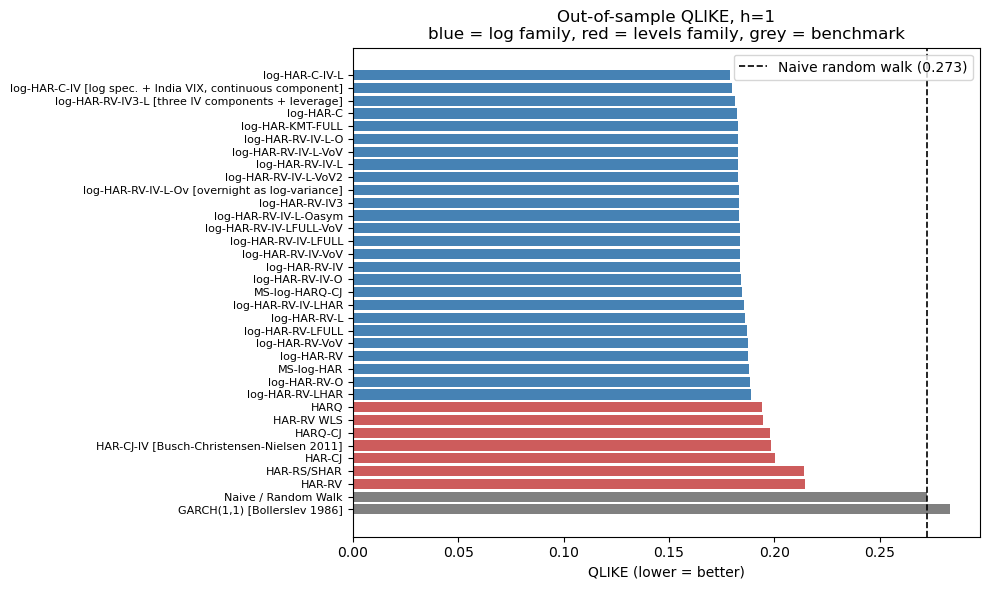

levels-family models WORSE than the naive random walk : 0 of 7
log-family models BETTER than the naive random walk   : 26 of 26


In [9]:
# QLIKE TEST
def qlike(y_true, y_pred):
    r = y_true / y_pred
    return r - np.log(r) - 1

def loss_table(df, names):
    rows = []
    for m in names:
        e = df[m] - df["actual"]
        rows.append({"Model": MODEL_SPECS[m].name,"family": MODEL_SPECS[m].family,"QLIKE": qlike(df["actual"], df[m]).mean(), "MSE_x1e9": (e ** 2).mean() * 1e9, "MAE_x1e5": e.abs().mean() * 1e5})
    return pd.DataFrame(rows).set_index("Model").sort_values("QLIKE")
print("FORECAST-CENSORING DIAGNOSTIC")
print(f"{'Model':14s}{'floor hits':>12s}{'worst-day QLIKE':>18s}{'mean QLIKE':>13s}")
for m in model_names:
    q = qlike(forecasts_h1["actual"], forecasts_h1[m])
    print(f"{m:14s}{FLOOR_HITS.get(m,0):12d}{q.max():18.2f}{q.mean():13.4f}")

loss_h1 = loss_table(forecasts_h1, model_names)
print(f"\n\nOUT-OF-SAMPLE LOSS, h={PRIMARY_HORIZON} "
      f"({len(forecasts_h1):,} origins)  -- lower is better")
loss_h1.round(4)

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"benchmark": "grey", "levels": "indianred", "log": "steelblue"}
srt = loss_h1.sort_values("QLIKE", ascending=True)
ax.barh(range(len(srt)), srt["QLIKE"], color=[colors[f] for f in srt["family"]])
ax.set_yticks(range(len(srt)))
ax.set_yticklabels(srt.index, fontsize=8)
ax.invert_yaxis()
naive_q = loss_h1.loc[MODEL_SPECS["Naive_RW"].name, "QLIKE"]
ax.axvline(naive_q, color="black", ls="--", lw=1.2,label=f"Naive random walk ({naive_q:.3f})")
ax.set_xlabel("QLIKE (lower = better)")
ax.set_title(f"Out-of-sample QLIKE, h={PRIMARY_HORIZON}\n"  "blue = log family, red = levels family, grey = benchmark")
ax.legend(); plt.tight_layout(); plt.show()
n_lev_worse = (loss_h1[loss_h1["family"] == "levels"]["QLIKE"] > naive_q).sum()
n_log_better = (loss_h1[loss_h1["family"] == "log"]["QLIKE"] < naive_q).sum()
print(f"levels-family models WORSE than the naive random walk : "
      f"{n_lev_worse} of {(loss_h1['family']=='levels').sum()}")
print(f"log-family models BETTER than the naive random walk   : "
      f"{n_log_better} of {(loss_h1['family']=='log').sum()}")

### Step 10: Forecast Comparison Test

In [10]:
# Diebold-Mariano test for equal predictive accuracy
def diebold_mariano(loss1, loss2, h=1):
    d = np.asarray(loss1) - np.asarray(loss2)
    n = len(d); dbar = d.mean()
    dc = d - dbar
    gamma0 = float(dc @ dc) / n
    cov = 0.0
    for k in range(1, int(h)):
        if k >= n:
            break
        gk = float(dc[k:] @ dc[:-k]) / n
        cov += 2.0 * (1.0 - k / float(h)) * gk          
    var_d = (gamma0 + cov) / n
    if not np.isfinite(var_d) or var_d <= 0:
        return np.nan, np.nan
    dm = dbar / np.sqrt(var_d)
    dm *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) 
    return dm, 2 * (1 - stats.t.cdf(abs(dm), df=n - 1))

# Clark-West test for nested models
def clark_west(y_true, f_restricted, f_unrestricted, h=1):
    y = np.asarray(y_true); fr = np.asarray(f_restricted); fu = np.asarray(f_unrestricted)
    adj = (y - fr) ** 2 - ((y - fu) ** 2 - (fr - fu) ** 2)
    res = sm.OLS(adj, np.ones(len(adj))).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    return float(res.params[0]), float(res.tvalues[0]), float(res.pvalues[0])

NESTED_IN = {
    "HAR_CJ": "HAR_RV", "HAR_RS": "HAR_RV", "HARQ": "HAR_RV",
    "HARQ_CJ": "HAR_CJ", "HAR_CJ_IV": "HAR_CJ", "MS_HARQ_CJ": "HARQ_CJ",
    "logHAR_RV_IV": "logHAR_RV", "logHAR_C_IV": "logHAR_C",
    "logHAR_RV_L": "logHAR_RV", "logHAR_RV_IV_L": "logHAR_RV_IV",
    "logHAR_RV_LHAR": "logHAR_RV", "logHAR_RV_IV_LHAR": "logHAR_RV_IV",
    "logHAR_RV_LFULL": "logHAR_RV", "logHAR_RV_IV_LFULL": "logHAR_RV_IV",
    "logHAR_RV_O": "logHAR_RV", "logHAR_RV_IV_O": "logHAR_RV_IV",
    "logHAR_RV_IV_L_O": "logHAR_RV_IV_L",
    "logHAR_RV_IV_L_Oasym": "logHAR_RV_IV_L",
    "logHAR_RV_IV_L_Ov": "logHAR_RV_IV_L",
    "logHAR_RV_IV3": "logHAR_RV_IV", "logHAR_RV_IV3_L": "logHAR_RV_IV_L",
    "logHAR_C_IV_L": "logHAR_C_IV",
    "logHAR_RV_VoV": "logHAR_RV",
    "logHAR_RV_IV_VoV": "logHAR_RV_IV",
    "logHAR_RV_IV_L_VoV": "logHAR_RV_IV_L",
    "logHAR_RV_IV_LFULL_VoV": "logHAR_RV_IV_LFULL",
    "logHAR_RV_IV_L_VoV2": "logHAR_RV_IV_L_VoV",
    "logHAR_KMT_FULL": "logHAR_RV_IV_L_O",
}

rows = []
for m, parent in NESTED_IN.items():
    _, cwt, cwp = clark_west(forecasts_h1["actual"].values, forecasts_h1[parent].values, forecasts_h1[m].values, h=PRIMARY_HORIZON)
    dmt, dmp = diebold_mariano(qlike(forecasts_h1["actual"], forecasts_h1[parent]).values,   qlike(forecasts_h1["actual"], forecasts_h1[m]).values,  h=PRIMARY_HORIZON)
    rows.append({"Model": m, "nesting parent": parent, "QLIKE gain": (qlike(forecasts_h1["actual"], forecasts_h1[parent]).mean() - qlike(forecasts_h1["actual"], forecasts_h1[m]).mean()), "CW t": cwt, "CW p": cwp, "DM t": dmt, "DM p": dmp})
print("NESTED COMPARISONS - each model vs its OWN nesting parent")
print("(positive QLIKE gain = the richer model helps; Clark-West is the valid test)\n")
pd.DataFrame(rows).set_index("Model").round(4)

NESTED COMPARISONS - each model vs its OWN nesting parent
(positive QLIKE gain = the richer model helps; Clark-West is the valid test)



,nesting parent,QLIKE gain,CW t,CW p,DM t,DM p
Model,,,,,,
HAR_CJ,HAR_RV,0.0141,1.7372,0.0824,2.4277,0.0154
HAR_RS,HAR_RV,0.0002,-0.0174,0.9862,0.0826,0.9342
HARQ,HAR_RV,0.0202,1.6479,0.0994,4.2426,0.0000
HARQ_CJ,HAR_CJ,0.0026,0.1302,0.8964,0.3688,0.7124
HAR_CJ_IV,HAR_CJ,0.0022,3.9658,0.0001,0.2456,0.8060
MS_HARQ_CJ,HARQ_CJ,0.0133,2.9659,0.0030,2.4098,0.0162
logHAR_RV_IV,logHAR_RV,0.0037,2.1404,0.0323,1.6984,0.0898
logHAR_C_IV,logHAR_C,0.0026,1.7397,0.0819,1.3644,0.1728
logHAR_RV_L,logHAR_RV,0.0013,0.7497,0.4534,0.5911,0.5546


In [11]:
# Model Confidence Test
def block_bootstrap_indices(n, block_len, n_boot, rng):
    nb = int(np.ceil(n / block_len))
    starts = rng.integers(0, n, size=(n_boot, nb))
    idx = np.empty((n_boot, nb * block_len), dtype=int)
    for b in range(n_boot):
        idx[b] = np.concatenate([np.arange(s, s + block_len) % n for s in starts[b]])
    return idx[:, :n]

def model_confidence_set(loss_df, alpha=0.10, n_boot=1000, block_len=10, seed=RNG_SEED):
    rng_ = np.random.default_rng(seed)
    surviving = list(loss_df.columns)
    eliminated = []
    n = loss_df.shape[0]
    boot_idx = block_bootstrap_indices(n, block_len, n_boot, rng_)

    while len(surviving) > 1:
        L = loss_df[surviving].values
        k = len(surviving)
        dbar_i = (L[:, :, None] - L[:, None, :]).mean(axis=0).sum(axis=1) / (k - 1)
        boot = np.empty((n_boot, k))
        for b in range(n_boot):
            Lb = L[boot_idx[b]]
            boot[b] = (Lb[:, :, None] - Lb[:, None, :]).mean(axis=0).sum(axis=1) / (k - 1)
        var_i = boot.var(axis=0, ddof=1); var_i[var_i <= 0] = np.nan
        t_i = dbar_i / np.sqrt(var_i)
        t_boot = (boot - dbar_i) / np.sqrt(var_i)
        p = np.mean(np.nanmax(np.abs(t_boot), axis=1) >= np.nanmax(np.abs(t_i)))
        if p > alpha:
            break
        if not np.isfinite(t_i).any():
            print("[MCS] all statistics non-finite; stopping elimination early")
            break
        worst = surviving[int(np.nanargmax(t_i))]
        eliminated.append((worst, p)); surviving.remove(worst)
    return surviving, eliminated
loss_matrix_h1 = pd.DataFrame({m: qlike(forecasts_h1["actual"], forecasts_h1[m])for m in model_names})
mcs_survivors, mcs_elim = model_confidence_set(loss_matrix_h1, alpha=0.10,   n_boot=1000, block_len=10)

print(f"MODEL CONFIDENCE SET (alpha=10%), QLIKE, h={PRIMARY_HORIZON}")
print(f"Superior Set of Models ({len(mcs_survivors)} of {len(model_names)}):")
for m in mcs_survivors:
    print(f"* [{MODEL_SPECS[m].family:9s}] {MODEL_SPECS[m].name}")
print("\nElimination order (worst first, p at removal):")
for m, p in mcs_elim:
    print(f"{MODEL_SPECS[m].name[:62]:62s} p={p:.3f}")

MODEL CONFIDENCE SET (alpha=10%), QLIKE, h=1
Superior Set of Models (12 of 35):
* [log      ] MS-log-HARQ-CJ
* [log      ] log-HAR-C
* [log      ] log-HAR-C-IV [log spec. + India VIX, continuous component]
* [log      ] log-HAR-RV-IV-L
* [log      ] log-HAR-RV-IV-L-O
* [log      ] log-HAR-RV-IV-L-Ov [overnight as log-variance]
* [log      ] log-HAR-RV-IV3
* [log      ] log-HAR-RV-IV3-L [three IV components + leverage]
* [log      ] log-HAR-C-IV-L
* [log      ] log-HAR-RV-IV-L-VoV
* [log      ] log-HAR-RV-IV-L-VoV2
* [log      ] log-HAR-KMT-FULL

Elimination order (worst first, p at removal):
GARCH(1,1) [Bollerslev 1986]                                   p=0.000
Naive / Random Walk                                            p=0.001
HAR-RS/SHAR                                                    p=0.000
HAR-RV                                                         p=0.000
HARQ-CJ                                                        p=0.004
HAR-RV WLS                                    

In [12]:
# Mincer Zarnowitz test
def mincer_zarnowitz(actual, pred, h=1, log_space=True):
    a_ = np.asarray(actual, float); p_ = np.asarray(pred, float)
    ok = np.isfinite(a_) & np.isfinite(p_) & (a_ > 0) & (p_ > 0)
    a_, p_ = a_[ok], p_[ok]
    if log_space:
        a_, p_ = np.log(a_), np.log(p_)
    X = sm.add_constant(p_)
    r = sm.OLS(a_, X).fit(cov_type="HAC", cov_kwds={"maxlags": int(max(1, h))})
    q = np.array([[0.0], [1.0]])                       
    f = r.f_test((np.eye(2), q))
    return {"a": float(r.params[0]), "b": float(r.params[1]), "R2": float(r.rsquared), "p": float(f.pvalue)}


In [13]:
# Benjamini-Hochberg FDR control
def benjamini_hochberg(pvals, names, alpha=0.10):
    p = np.asarray(pvals, float)
    ok = np.isfinite(p)
    idx = np.argsort(np.where(ok, p, np.inf))
    m = int(ok.sum())
    if m == 0:
        return set()
    thresh = (np.arange(1, m + 1) / m) * alpha
    passed = p[idx][:m] <= thresh
    kmax = int(np.max(np.where(passed)[0])) + 1 if passed.any() else 0
    return {names[i] for i in idx[:kmax]}

def influence_report(actual, f_a, f_b, index, top=5):
    d = qlike(actual, f_a) - qlike(actual, f_b)
    v = (d - d.mean()) ** 2
    share = v / v.sum()
    order = np.argsort(-share)[:top]
    return pd.DataFrame({
        "date": [index[i].date() for i in order],
        "d": d[order],
        "share_of_var_%": 100 * share[order],
    })

def dm_trimmed(actual, f_a, f_b, k=1, h=1):
    d = qlike(actual, f_a) - qlike(actual, f_b)
    if k > 0:
        keep = np.sort(np.argsort(-np.abs(d - d.mean()))[k:])
        d = d[keep]
    n = len(d)
    var_d = np.var(d, ddof=0) / n
    if not np.isfinite(var_d) or var_d <= 0:
        return np.nan, np.nan
    t = d.mean() / np.sqrt(var_d) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return t, 2 * (1 - stats.t.cdf(abs(t), df=n - 1))

INCUMBENT = "logHAR_RV_IV"
_a = forecasts_h1["actual"].values
_rows = []
for m in model_names:
    if m == INCUMBENT:
        continue
    l_inc = qlike(_a, forecasts_h1[INCUMBENT].values)
    l_m= qlike(_a, forecasts_h1[m].values)
    t_, p_ = diebold_mariano(l_inc, l_m, PRIMARY_HORIZON)
    t_tr, p_tr = dm_trimmed(_a, forecasts_h1[INCUMBENT].values, forecasts_h1[m].values, k=1, h=PRIMARY_HORIZON)
    _rows.append({"Model": MODEL_SPECS[m].name[:52], "key": m,"QLIKE": l_m.mean(), "DM t": t_, "DM p": p_, "DM p (-1 day)": p_tr, "DM t (-1 day)": t_tr})
fdr_tab = pd.DataFrame(_rows).sort_values("QLIKE").reset_index(drop=True)

_sig_raw  = benjamini_hochberg(fdr_tab["DM p"].values,  list(fdr_tab["key"]), alpha=0.10)
_sig_trim = benjamini_hochberg(fdr_tab["DM p (-1 day)"].values, list(fdr_tab["key"]), alpha=0.10)
fdr_tab["BH 10%"]= ["YES" if k in _sig_raw  else "" for k in fdr_tab["key"]]
fdr_tab["BH 10% (-1 d)"] = ["YES" if k in _sig_trim else "" for k in fdr_tab["key"]]
fdr_tab["better?"] = np.where(fdr_tab["DM t"] > 0, "better", "WORSE")
fdr_tab["in MCS"]  = ["YES" if any(MODEL_SPECS[k].name == MODEL_SPECS[kk].name for kk in mcs_survivors) else ""     for k in fdr_tab["key"]]

print(f"DM vs {MODEL_SPECS[INCUMBENT].name}, with Benjamini-Hochberg FDR at 10%")
print(fdr_tab.drop(columns=["key"]).to_string(index=False,  float_format=lambda x: f"{x:8.4f}"))
print(f"\n\nMCS retains {len(mcs_survivors)} of {len(model_names)} models.")
print(f"BH(10%) flags {len(_sig_raw)} of {len(fdr_tab)} comparisons as significantly different;")
print(f"   of those, {sum((fdr_tab['BH 10%']=='YES') & (fdr_tab['DM t']>0))} are BETTER "
      f"and {sum((fdr_tab['BH 10%']=='YES') & (fdr_tab['DM t']<0))} are WORSE.")

_worst_in_mcs = fdr_tab[fdr_tab["in MCS"] == "YES"].sort_values("QLIKE").tail(1)

print("\n\nINFLUENCE DIAGNOSTIC - headline comparison")
_best = fdr_tab.iloc[0]["key"]
print(f"   {MODEL_SPECS[INCUMBENT].name[:44]}  vs  {MODEL_SPECS[_best].name[:44]}")
print(influence_report(_a, forecasts_h1[INCUMBENT].values,   forecasts_h1[_best].values, forecasts_h1.index, top=5)  .to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
_t_raw, _p_raw = diebold_mariano(qlike(_a, forecasts_h1[INCUMBENT].values),     qlike(_a, forecasts_h1[_best].values), PRIMARY_HORIZON)
_t_tr, _p_tr = dm_trimmed(_a, forecasts_h1[INCUMBENT].values,  forecasts_h1[_best].values, k=1, h=PRIMARY_HORIZON)
print(f"\n   DM raw          t={_t_raw:+.3f}  p={_p_raw:.4f}")
print(f" DM minus 1 day  t={_t_tr:+.3f}  p={_p_tr:.4f}")

_mz_set = list(mcs_survivors) if ("mcs_survivors" in dir() and len(mcs_survivors)) else \
          list(pd.Series({m: qlike(forecasts_h1["actual"], forecasts_h1[m]).mean()  for m in model_names}).sort_values().index[:10])
_mz_set = list(dict.fromkeys(_mz_set + [m for m in ("logHAR_RV", "HAR_RV", "Naive_RW") if m in forecasts_h1]))
_rows = []
for _m in _mz_set:
    _z = mincer_zarnowitz(forecasts_h1["actual"].values, forecasts_h1[_m].values,  h=PRIMARY_HORIZON, log_space=True)
    _rows.append({"Model": MODEL_SPECS[_m].name[:46], "a": _z["a"], "b": _z["b"],"R2": _z["R2"], "p (a=0 & b=1)": _z["p"],"QLIKE": qlike(forecasts_h1["actual"], forecasts_h1[_m]).mean()})
_mz_tab = pd.DataFrame(_rows).sort_values("QLIKE").reset_index(drop=True)
print("RQ6  MINCER-ZARNOWITZ, log space, joint null H0: (a, b) = (0, 1)")
print("     candidate set: MCS superior set plus benchmarks\n")
print(_mz_tab.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
_rej = benjamini_hochberg(_mz_tab["p (a=0 & b=1)"].values, list(_mz_tab["Model"]), alpha=ALPHA_FDR)
print(f"\n  efficiency null REJECTED at BH-FDR {ALPHA_FDR:.0%} for "
      f"{len(_rej)} of {len(_mz_tab)} models")
print("b > 1 : the forecast UNDER-reacts (too smooth).  b < 1 : it OVER-reacts.")

DM vs log-HAR-RV-IV, with Benjamini-Hochberg FDR at 10%
                                               Model    QLIKE     DM t     DM p  DM p (-1 day)  DM t (-1 day) BH 10% BH 10% (-1 d) better? in MCS
                                      log-HAR-C-IV-L   0.1790   1.7898   0.0739         0.0173         2.3854                  YES  better    YES
log-HAR-C-IV [log spec. + India VIX, continuous comp   0.1798   2.0113   0.0446         0.0031         2.9650                  YES  better    YES
   log-HAR-RV-IV3-L [three IV components + leverage]   0.1814   0.7855   0.4324         0.0494         1.9680                       better    YES
                                           log-HAR-C   0.1824   0.4814   0.6304         0.3229         0.9891                       better    YES
                                    log-HAR-KMT-FULL   0.1828   0.4505   0.6525         0.3004         1.0362                       better    YES
                                   log-HAR-RV-IV-L-O   0.1828   0.44

### Step 11: Robustness Tests: VaR Backetesting

In [14]:
# VaR backtesting 
VAR_LEVELS = [0.01, 0.05]        # 99% and 95% VaR (left tail of returns)
VAR_WARMUP = 100                 

_VAR_BASELINES = [m for m in ("logHAR_RV_IV", "logHAR_RV", "Naive_RW") if m in forecasts_h1]
if "mcs_survivors" in dir() and len(mcs_survivors):
    _VAR_SET, _VAR_SRC = list(mcs_survivors), f"MCS superior set ({len(mcs_survivors)} models)"
else:                                        # MCS cell not run - fall back, and say so
    _VAR_SET = list(pd.Series({m: qlike(forecasts_h1["actual"], forecasts_h1[m]).mean()
                               for m in model_names}).sort_values().index[:5])
    _VAR_SRC = "top 5 by QLIKE (MCS not available - EX-POST, interpret with care)"
VAR_MODELS = list(dict.fromkeys(_VAR_SET + _VAR_BASELINES))
_VAR_REF = min(VAR_MODELS, key=lambda m: qlike(forecasts_h1["actual"], forecasts_h1[m]).mean())
print(f"VaR candidate set: {_VAR_SRC}")
print(f"  {len(VAR_MODELS)} models backtested; diagnostic reference = "
      f"{MODEL_SPECS[_VAR_REF].name[:50]}")
_r_intra_all = (np.log(day_close) - np.log(day_open)).reindex(feat.index)
_r_c2c_all   = feat["ret_d"]
_r_next = { "intraday (open-to-close)": _r_intra_all.shift(-1).reindex(forecasts_h1.index).values, "close-to-close":  _r_c2c_all.shift(-1).reindex(forecasts_h1.index).values,}

_train_mask = feat.index < forecasts_h1.index.min()
assert _train_mask.sum() > 0 and not _train_mask[feat.index >= forecasts_h1.index.min()].any(), \
    "training mask overlaps the evaluation window"
_z_train = (_r_intra_all[_train_mask] /
            np.sqrt(feat.loc[_train_mask, "RV"].clip(lower=1e-16))).dropna()
_nu = float(stats.t.fit(_z_train.values)[0])
_nu = min(max(_nu, 2.5), 50.0)
print(f"\nStudent-t df estimated on TRAINING standardised returns only: nu = {_nu:.2f}"
      f"   (n={len(_z_train)}, up to {feat.index[_train_mask].max().date()})")
_r_eval  = _r_next["intraday (open-to-close)"]
_rv_eval = feat["RV"].shift(-1).reindex(forecasts_h1.index).values
_okd     = np.isfinite(_r_eval) & np.isfinite(_rv_eval) & (_rv_eval > 0)
_u       = _r_eval[_okd] / np.sqrt(_rv_eval[_okd])
_sd_u    = float(np.std(_u))
_exkurt  = float(stats.kurtosis(_u))            # Fisher: 0 == Gaussian
_skew_u  = float(stats.skew(_u))
_bias    = float(np.mean(forecasts_h1[_VAR_REF].values[_okd]) / np.mean(_rv_eval[_okd]))

def var_forecast(rv_hat, tau, dist="gaussian", nu=None):
    sig = np.sqrt(np.asarray(rv_hat))
    if dist == "gaussian":
        q = stats.norm.ppf(tau)
    else:                                   # standardised so Var = 1
        q = stats.t.ppf(tau, nu) * np.sqrt((nu - 2.0) / nu)
    return sig * q

def corrected_var(rv_hat, r_realised, tau, warmup=VAR_WARMUP, use_skew=True):
    rv_hat = np.asarray(rv_hat, float)
    r = np.asarray(r_realised, float)
    n = len(rv_hat)
    z = stats.norm.ppf(tau)
    out = np.full(n, np.nan)
    corrected = np.zeros(n, dtype=bool)
    u_hist = r / np.sqrt(rv_hat)                      
    for i in range(n):
        past = u_hist[:i]                            
        past = past[np.isfinite(past)]
        if len(past) < warmup:
            c, sk = 1.0, 0.0                      
        else:
            c = float(np.std(past))
            sk = float(stats.skew(past)) if use_skew else 0.0
            corrected[i] = True
        q = z + (z ** 2 - 1) / 6 * sk if use_skew else z
        out[i] = c * np.sqrt(rv_hat[i]) * q
    return out, corrected

def _assert_corrected_var_causal(rv_hat, r, tau=0.01):
    rv_hat = np.asarray(rv_hat, float); r = np.asarray(r, float)
    k = len(r) // 2
    a, _ = corrected_var(rv_hat, r, tau)
    r_bad = r.copy(); r_bad[k:] = -np.abs(r_bad[k:]) * 25.0 - 1.0
    b, _ = corrected_var(rv_hat, r_bad, tau)
    assert np.allclose(a[:k + 1], b[:k + 1], equal_nan=True), \
        "corrected_var LEAKS: future returns changed a past VaR value"
    assert not np.allclose(a[k + 1:], b[k + 1:], equal_nan=True), \
        "corrected_var ignores its history entirely - the correction is not active"
    return True

def kupiec_uc(hits, tau):
    n = len(hits); x = int(np.sum(hits))
    if x == 0 or x == n:
        return np.nan, np.nan
    ph = x / n
    lr = -2 * ((n - x) * np.log(1 - tau) + x * np.log(tau)  - (n - x) * np.log(1 - ph) - x * np.log(ph))
    return lr, 1 - stats.chi2.cdf(lr, 1)

def christoffersen_cc(hits, tau):
    h = np.asarray(hits).astype(int)
    n00 = n01 = n10 = n11 = 0
    for a, b in zip(h[:-1], h[1:]):
        if   a == 0 and b == 0: n00 += 1
        elif a == 0 and b == 1: n01 += 1
        elif a == 1 and b == 0: n10 += 1
        else:                   n11 += 1
    if (n00 + n01) == 0 or (n10 + n11) == 0 or n01 == 0 or n11 == 0:
        return np.nan, np.nan
    p01 = n01 / (n00 + n01); p11 = n11 / (n10 + n11)
    p   = (n01 + n11) / (n00 + n01 + n10 + n11)
    lr_ind = -2 * (((n00 + n10) * np.log(1 - p) + (n01 + n11) * np.log(p)) - (n00 * np.log(1 - p01) + n01 * np.log(p01)  + n10 * np.log(1 - p11) + n11 * np.log(p11)))
    lr_uc, _ = kupiec_uc(h, tau)
    if not np.isfinite(lr_uc):
        return np.nan, np.nan
    cc = lr_uc + lr_ind
    return cc, 1 - stats.chi2.cdf(cc, 2)

def dq_test(hits, var_series, tau, lags=4):
    h = np.asarray(hits).astype(float) - tau
    n = len(h)
    if n <= lags + 2:
        return np.nan, np.nan
    Z = [np.ones(n - lags)]
    for L in range(1, lags + 1):
        Z.append(h[lags - L: n - L])
    Z.append(np.asarray(var_series)[lags:])
    X = np.column_stack(Z); y = h[lags:]
    try:
        b = np.linalg.pinv(X.T @ X) @ (X.T @ y)
        stat = float(b @ (X.T @ X) @ b / (tau * (1 - tau)))
    except Exception:
        return np.nan, np.nan
    return stat, 1 - stats.chi2.cdf(stat, X.shape[1])

def basel_zone_count(n_exceed):
    if n_exceed <= 4:  return "GREEN",  3.00
    if n_exceed == 5:  return "YELLOW", 3.40
    if n_exceed == 6:  return "YELLOW", 3.50
    if n_exceed == 7:  return "YELLOW", 3.65
    if n_exceed == 8:  return "YELLOW", 3.75
    if n_exceed == 9:  return "YELLOW", 3.85
    return "RED", 4.00

def basel_rolling(hits, window=250):
    h = pd.Series(np.asarray(hits).astype(int))
    roll = h.rolling(window).sum().dropna()
    if len(roll) == 0:
        return None
    zones = roll.map(lambda n: basel_zone_count(int(n))[0])
    worst = int(roll.max())
    return {"n_windows": len(roll),
            "pct_green":  100 * (zones == "GREEN").mean(),
            "pct_yellow": 100 * (zones == "YELLOW").mean(),
            "pct_red":    100 * (zones == "RED").mean(),
            "worst_count": worst,
            "worst_zone":  basel_zone_count(worst)[0],
            "modal_zone":  zones.mode().iloc[0],
            "mean_mult":   float(roll.map(lambda n: basel_zone_count(int(n))[1]).mean())}

def lopez_loss(r, var_, hits):
    return np.where(hits, 1.0 + (np.asarray(r) - np.asarray(var_)) ** 2, 0.0).mean()

def tick_loss(r, var_, tau):
    r = np.asarray(r); v = np.asarray(var_)
    return ((tau - (r < v).astype(float)) * (r - v)).mean()

_chk_ok = np.isfinite(_r_next["intraday (open-to-close)"])
assert _assert_corrected_var_causal(forecasts_h1[_VAR_REF].values[_chk_ok],
                                    _r_next["intraday (open-to-close)"][_chk_ok])
print("\n[PASS] corrected_var is causal: corrupting the second half of the return series"
      "\nleaves every earlier VaR value bit-for-bit unchanged.")

_ov_share = 100 * ov["RV_overnight"].sum() / ov["RV_total"].sum()

var_tables = {}
for _ret_name, _r_next_vals in _r_next.items():
    _ok = np.isfinite(_r_next_vals)
    _r = _r_next_vals[_ok]
    print("\n" + "=" * 122)
    print(f"VaR BACKTEST - {_ret_name} returns   (n = {int(_ok.sum())} days, "
          f"{len(VAR_MODELS)} models x 3 mappings x {len(VAR_LEVELS)} levels)")
    if _ret_name.startswith("close-to-close"):
        print(f"NOTE: deliberately MISMATCHED. RV excludes the overnight gap ({_ov_share:.1f}% of")
        print("total daily variance), so under-coverage here measures the cost of the")
        print("  trading-time convention, NOT a defect of the forecasting model.")
    print("=" * 122)
    rows = []
    for _tau in VAR_LEVELS:
        for _m in VAR_MODELS:
            _rvh = forecasts_h1[_m].values[_ok]
            _cv, _flag = corrected_var(_rvh, _r, _tau)
            _methods = {"plug-in Gaussian":  var_forecast(_rvh, _tau, "gaussian"),"plug-in Student-t": var_forecast(_rvh, _tau, "student-t", _nu),"scale + Cornish-Fisher": _cv,
            }
            for _mn, _v in _methods.items():
                _hits = (_r < _v)
                _, p_uc = kupiec_uc(_hits, _tau)
                _, p_cc = christoffersen_cc(_hits, _tau)
                _, p_dq = dq_test(_hits, _v, _tau)
                _b = basel_rolling(_hits) if abs(_tau - 0.01) < 1e-9 else None
                rows.append({
                    "level": f"{1-_tau:.0%}", "method": _mn,
                    "model": MODEL_SPECS[_m].name[:34],
                    "VRate %": 100 * _hits.mean(), "exp %": 100 * _tau,
                    "Kupiec p": p_uc, "Christ p": p_cc, "DQ p": p_dq,
                    "%green": _b["pct_green"] if _b else np.nan,
                    "%yellow": _b["pct_yellow"] if _b else np.nan,
                    "%red": _b["pct_red"] if _b else np.nan,
                    "worst": f"{_b['worst_count']}({_b['worst_zone'][:1]})" if _b else "n/a",
                    "Lopez": lopez_loss(_r, _v, _hits),
                    "Tick x1e4": 1e4 * tick_loss(_r, _v, _tau)})
    _tab = pd.DataFrame(rows).sort_values(["level", "method", "VRate %"])
    print(_tab.to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
    var_tables[_ret_name] = _tab
var_table_intraday = var_tables["intraday (open-to-close)"]

VaR candidate set: MCS superior set (12 models)
  15 models backtested; diagnostic reference = log-HAR-C-IV-L

Student-t df estimated on TRAINING standardised returns only: nu = 50.00   (n=1941, up to 2022-12-29)

[PASS] corrected_var is causal: corrupting the second half of the return series
leaves every earlier VaR value bit-for-bit unchanged.

VaR BACKTEST - intraday (open-to-close) returns   (n = 832 days, 15 models x 3 mappings x 2 levels)
level                 method                              model  VRate %    exp %  Kupiec p  Christ p     DQ p   %green  %yellow     %red worst    Lopez  Tick x1e4
  95%       plug-in Gaussian                     log-HAR-RV-IV3   5.7692   5.0000    0.3198    0.5338   0.3167      NaN      NaN      NaN   n/a   0.0577     8.8195
  95%       plug-in Gaussian log-HAR-RV-IV3-L [three IV compone   5.8894   5.0000    0.2517    0.4368   0.2335      NaN      NaN      NaN   n/a   0.0589     8.8468
  95%       plug-in Gaussian                      log-HAR-R

## **RQ3: In which Volatility regime does each block earn its gain?**

### Step 12: Regime decomposition

In [15]:
_act = forecasts_h1["actual"].values
_LQ  = {m: qlike(_act, forecasts_h1[m].values) for m in model_names}

_cut_post  = np.quantile(_act, REGIME_Q)
_turb_post = _act >= _cut_post

_thr_ex = feat["RV"].expanding(min_periods=REGIME_MIN).quantile(REGIME_Q).shift(1)
_state  = (feat["RV"] >= _thr_ex).reindex(forecasts_h1.index)
_turb_ex = _state.fillna(False).values.astype(bool)
_n_undef = int(_state.isna().sum())

print(f"EX-ANTE split : RV_t >= expanding {REGIME_Q:.0%} quantile of past RV "
      f"(min {REGIME_MIN} obs)")
print(f"   calm {int((~_turb_ex).sum())}   turbulent {int(_turb_ex.sum())}"
      f"   undefined {_n_undef}")
print(f"EX-POST split : realised RV >= its own {REGIME_Q:.0%} quantile "
      f"(annualised {100*np.sqrt(_cut_post*TRADING_DAYS_PER_YEAR):.1f}%)")
print(f"   calm {int((~_turb_post).sum())}   turbulent {int(_turb_post.sum())}")
print(f"AGREEMENT between the two classifications: "
      f"{100*np.mean(_turb_ex == _turb_post):.1f}%\n")

_blocks = [
    ("Implied vol (India VIX)",  "logHAR_RV",          "logHAR_RV_IV",           "standalone"),
    ("Leverage, daily",          "logHAR_RV",          "logHAR_RV_L",            "standalone"),
    ("Leverage, d/w/m",          "logHAR_RV",          "logHAR_RV_LFULL",        "standalone"),
    ("Overnight return",         "logHAR_RV",          "logHAR_RV_O",            "standalone"),
    ("Vol-of-vol",               "logHAR_RV",          "logHAR_RV_VoV",          "standalone"),
    ("Leverage | IV present",    "logHAR_RV_IV",       "logHAR_RV_IV_L",         "marginal"),
    ("Implied vol | lev present","logHAR_RV_L",        "logHAR_RV_IV_L",         "marginal"),
    ("Overnight | IV+lev",       "logHAR_RV_IV_L",     "logHAR_RV_IV_L_O",       "marginal"),
    ("Vol-of-vol | IV+lev",      "logHAR_RV_IV_L",     "logHAR_RV_IV_L_VoV",     "marginal"),
    ("Vol-of-vol | IV+lev(full)","logHAR_RV_IV_LFULL", "logHAR_RV_IV_LFULL_VoV", "marginal"),
]

def _regime_rows(turb, tag):
    rows = []
    for lbl, par, chi, kind in _blocks:
        if par not in _LQ or chi not in _LQ:
            continue
        d = _LQ[par] - _LQ[chi]
        _, p_all  = diebold_mariano(_LQ[par], _LQ[chi], PRIMARY_HORIZON)
        _, p_calm = diebold_mariano(_LQ[par][~turb], _LQ[chi][~turb], PRIMARY_HORIZON)
        _, p_turb = diebold_mariano(_LQ[par][turb],  _LQ[chi][turb],  PRIMARY_HORIZON)
        rows.append({"Block added": lbl, "type": kind,"all days": d.mean(), "p(all)": p_all, "calm": d[~turb].mean(), "p(calm)": p_calm, "turb": d[turb].mean(), "p(turb)": p_turb, "lives in": ("TURBULENT" if d[turb].mean() > d[~turb].mean() else "CALM")})
    return pd.DataFrame(rows)

regime_gain    = _regime_rows(_turb_ex,  "ex-ante")
regime_gain_xp = _regime_rows(_turb_post, "ex-post")

print("QLIKE GAIN BY REGIME - EX-ANTE state (primary; implementable)")
print("positive = the added block IMPROVES the forecast\n")
print(regime_gain.to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
print("\n\nQLIKE GAIN BY REGIME - EX-POST state (descriptive only)\n")
print(regime_gain_xp.to_string(index=False, float_format=lambda x: f"{x:8.4f}"))
_flip = [r["Block added"] for (_, r), (_, q) in zip(regime_gain.iterrows(),  regime_gain_xp.iterrows())if r["lives in"] != q["lives in"]]
print(f"\n\nBlocks whose 'where it lives' verdict DIFFERS between the two splits: "
      f"{_flip if _flip else 'none'}")

EX-ANTE split : RV_t >= expanding 67% quantile of past RV (min 250 obs)
   calm 649   turbulent 183   undefined 0
EX-POST split : realised RV >= its own 67% quantile (annualised 12.0%)
   calm 554   turbulent 278
AGREEMENT between the two classifications: 74.2%

QLIKE GAIN BY REGIME - EX-ANTE state (primary; implementable)
positive = the added block IMPROVES the forecast

              Block added       type  all days   p(all)     calm  p(calm)     turb  p(turb)  lives in
  Implied vol (India VIX) standalone    0.0037   0.0898   0.0044   0.0723   0.0013   0.7870      CALM
          Leverage, daily standalone    0.0013   0.5546   0.0022   0.1725  -0.0019   0.8165      CALM
          Leverage, d/w/m standalone    0.0005   0.8465   0.0023   0.2001  -0.0058   0.6037      CALM
         Overnight return standalone   -0.0008   0.4121  -0.0011   0.3468   0.0004   0.7216 TURBULENT
               Vol-of-vol standalone    0.0000   0.9908  -0.0000   0.9913   0.0000   0.9732 TURBULENT
    Leverage 

### Step 12: Summary

In [16]:
def encompassing(actual, f_simple, f_rich, h=1):
    e = ( np.asarray(actual, float)- np.asarray(f_simple, float))
    d = (np.asarray(f_simple, float) - np.asarray(f_rich, float) )
    ok = ( np.isfinite(e) & np.isfinite(d))
    if ok.sum() < 30 or np.allclose(d[ok], 0):
        return np.nan, np.nan
    r = sm.OLS( e[ok], sm.add_constant(d[ok])).fit( cov_type="HAC", cov_kwds={ "maxlags": int(max(1, h))})
    return (float(r.params[1]), float(r.pvalues[1]))

def _h_returns(index, h):
    r1 = ( np.log(day_close)- np.log(day_open)).reindex(feat.index)
    cum = ( r1[::-1] .rolling(h).sum()[::-1] .shift(-1))
    return cum.reindex(index).values

def exante_regime(index,q=REGIME_Q, min_periods=REGIME_MIN):
    rv = feat["RV"]
    thr = ( rv .expanding(min_periods=min_periods).quantile(q).shift(1))
    ind = (rv >= thr).where( thr.notna())
    out = ind.reindex(index)
    return (out, int(out.isna().sum()))

def var_backtest_h(rv_hat_mean, r_cum, h, tau=VAR_TAU, warmup=60, contiguous=True):
    rv = np.asarray( rv_hat_mean, float )
    r = np.asarray( r_cum, float)
    keep = np.zeros( len(rv), dtype=bool)
    keep[::h] = True
    ok = ( keep & np.isfinite(rv) & np.isfinite(r) & (rv > 0))
    rv = rv[ok]
    r = r[ok]
    n = len(rv)
    if n < warmup + 20:
        return {"n_eff": n,"VRate": np.nan,  "p_uc": np.nan, "p_cc": np.nan, "p_dq": np.nan, "zone": "n/a", "informative": False}
    z = stats.norm.ppf(tau)
    u = ( r / np.sqrt(h * rv))
    v = np.empty(n)
    for i in range(n):
        past = u[:i]
        past = past[ np.isfinite(past)]
        if len(past) < warmup:
            c = 1.0
            sk = 0.0
        else:
            c = float( np.std(past))
            sk = float( stats.skew(past))
        v[i] = c * np.sqrt(h * rv[i]) * (z + ((z**2 - 1) / 6) * sk)
    hits = r < v
    _, p_uc = kupiec_uc( hits,tau)
    _, p_cc = christoffersen_cc( hits, tau)
    _, p_dq = dq_test( hits, v, tau, lags=min( 4, max( 1, n // 20)))
    if ( abs(tau - 0.01) < 1e-9 and h == 1 and contiguous):
        _b = basel_rolling(hits)
        _zone = ( _b["worst_zone"] if _b else "n/a")
    else:
        _zone = "n/a"
    return { "n_eff": n,"VRate": 100 * hits.mean(),"p_uc": p_uc, "p_cc": p_cc, "p_dq": p_dq, "zone": _zone, "informative": (tau * n >= 10 )}

def general_to_specific( cands, L, df, a, h):
    start = min(cands, key=lambda m: L[m].mean())
    cur = start
    path = [start]
    log = []
    seen = {start}
    while True:
        par = NESTED_IN.get(cur)
        if ( par is None or par not in L or par in seen):
            break
        _, cwt, cwp2 = clark_west( a,df[par].values,df[cur].values, h=h)
        cw = ( cwp2 / 2 if cwt > 0 else 1 - cwp2 / 2)
        _, dm_par = diebold_mariano( L[par], L[cur], h )
        _, dm_start = diebold_mariano( L[par], L[start], h)
        _, dm_par_trim = dm_trimmed(a, df[par].values,df[cur].values, k=1, h=h)
        cw_support = ( np.isfinite(cw) and cw < ALPHA_PARENT)
        dm_support = ( np.isfinite(dm_par) and dm_par < ALPHA_FDR )
        keep_rich = ( cw_support or dm_support)
        drifted = ( np.isfinite(dm_start) and dm_start < ALPHA_FDR)
        keep_rich_trim = ( cw_support or ( np.isfinite(dm_par_trim)  and dm_par_trim < ALPHA_FDR))
        fragile = ( keep_rich != keep_rich_trim)
        log.append({ "from": cur, "to": par, "CW_p": cw, "DM_p_vs_parent": dm_par, "DM_p_trim": dm_par_trim, "DM_p_vs_start": dm_start, "fragile": bool(fragile), "keep_rich": bool(keep_rich), "verdict": ( "retain_rich" if keep_rich else "reduce_to_parent" )})
        if keep_rich:
            break
        if drifted:
            break
        cur = par
        path.append(cur)
        seen.add(cur)
    return (cur, path, log )

def _evaluate( keys, df, a, h, run_var, tag):
    L = {m: qlike( a, df[m].values) for m in keys}
    mu = (pd.Series({ m: v.mean() for m, v in L.items()}).sort_values())
    lead = mu.index[0]
    if ( len(a) >= MIN_REGIME_N and len(keys) > 1):
        mcs, _ = model_confidence_set( pd.DataFrame({ m: L[m] for m in keys}),alpha=ALPHA_MCS,n_boot=1000,block_len=max(10, h),seed=MCS_SEED)
    else:
        mcs = list(keys)
    others = [ m for m in mu.index if m != lead]
    dm = {m: diebold_mariano( L[m], L[lead], h) for m in others}
    dmt = {m: dm_trimmed( a, df[m].values, df[lead].values, k=1, h=h) for m in others}
    worse = benjamini_hochberg( [dm[m][1] for m in others],others,alpha=ALPHA_FDR)
    rows = []

    for m in mu.index:
        mz = mincer_zarnowitz( a, df[m].values, h=h, log_space=True)
        par = NESTED_IN.get(m)
        if par in L:
            _, cwt, cwp2 = clark_west( a, df[par].values, df[m].values, h=h)
            cw = (cwp2 / 2 if cwt > 0 else 1 - cwp2 / 2)
        else:
            cw = np.nan
        vr = (var_backtest_h( df[m].values, _h_returns( df.index, h), h, contiguous=( tag == "ALL" ))if ( run_var and m in mcs)else None)
        rows.append({
            "key": m,
            "Model": MODEL_SPECS[m].name,
            "k": len( MODEL_SPECS[m].regressors),
            "QLIKE": mu[m],
            "gap%": ( 100 * ( mu[m] / mu[lead] - 1 )),
            "MCS": m in mcs,
            "DM_p": ( np.nan if m == lead else dm[m][1]),
            "DM_p_trim": ( np.nan if m == lead else dmt[m][1]),
            "BH_worse": ( m in worse),
            "MZ_b": mz["b"],
            "MZ_p": mz["p"],
            "CW_parent_p": cw,
            "earns_block": (np.nan if not np.isfinite(cw) else cw < ALPHA_PARENT ),
            "VaR_n": ( vr["n_eff"] if vr else np.nan),
            "VaR_rate": ( vr["VRate"] if vr else np.nan),
            "VaR_uc": ( vr["p_uc"] if vr else np.nan),
            "VaR_dq": ( vr["p_dq"] if vr else np.nan),
            "VaR_info": ( bool(vr["informative"])if vr else False),
            "VaR_ok": ( None if (  not vr or not vr["informative"]) else bool(( not np.isfinite( vr["p_uc"]) or vr["p_uc"] > ALPHA_TEST) and (not np.isfinite( vr["p_dq"]) or vr["p_dq"] > ALPHA_TEST) and vr["zone"]!= "RED"))})

    tab = pd.DataFrame(rows)
    tab["adequate"] = ( tab["MCS"] & tab["VaR_ok"].map( lambda v: v is not False ))
    cand = ( list( tab.loc[ tab["adequate"], "key" ]) or list(tab.loc[ tab["MCS"],"key"]) or list( tab["key"]))
    chosen, path, log = general_to_specific( cand, L, df, a, h)
    return {"tab": tab,"lead": lead,"mcs": mcs, "cand": cand, "chosen": chosen, "path": path, "log": log, "n": len(a), "L": L}

protocol = {}
RECOMMENDED = {}
for _h, _df0 in forecasts_by_h.items():
    _reg_ex, _n_undef = exante_regime( _df0.index)
    _a0 = _df0["actual"].values
    _cut = np.quantile( _a0, REGIME_Q)
    _post = pd.Series(_a0 >= _cut,index=_df0.index)
    _both = _reg_ex.notna()
    _agree = float(( _reg_ex[_both].astype(bool) == _post[_both]).mean())
    assert ( _reg_ex.index.equals(_df0.index)), "regime indicator misaligned to origins"
    assert ( _n_undef == int(_reg_ex.isna().sum())), "undefined-regime count inconsistent"
    _slices = {"ALL":np.ones( len(_df0), dtype=bool),"CALM":( _reg_ex .fillna(False) .values == False) & _both.values, "TURBULENT":( _reg_ex .fillna(False) .values == True)& _both.values}
    res = {}
    for _tag, _mask in _slices.items():
        if ( _mask.sum() < MIN_REGIME_N and _tag != "ALL"):
            res[_tag] = None
            continue
        _d = _df0.loc[_mask]
        res[_tag] = _evaluate(model_names, _d, _d["actual"].values, _h, run_var=(_tag == "ALL"), tag=_tag)

    protocol[_h] = { "res": res, "agree": _agree,"n_undef": _n_undef, "cut": _cut,"n": len(_df0), "n_turb_ex":int( _slices[ "TURBULENT" ].sum()), "n_calm_ex":int( _slices[ "CALM"].sum())}
    RECOMMENDED[_h] = {t: ( r["chosen"] if r else None ) for t, r in res.items()}

for _h in HORIZONS:
    P = protocol[_h]
    print(f"\nh = {_h}")
    rows_main = []
    for _tag in ( "ALL", "CALM", "TURBULENT"):
        R = P["res"][_tag]
        if R is None:
            rows_main.append({"regime": _tag, "recommended": np.nan,"k": np.nan, "QLIKE": np.nan,"started_from": np.nan,"reduction": np.nan,"MCS": np.nan,"adequate": np.nan  })
            continue
        _ch = R["chosen"]
        _st = R["path"][0]
        if _ch == _st:
            _red = "none"
        else:
          _red = " -> ".join(MODEL_SPECS[m].name .split(" [")[0] for m in R["path"])
        rows_main.append({ "regime": _tag, "recommended": MODEL_SPECS[_ch].name,"k": len( MODEL_SPECS[_ch] .regressors ), "QLIKE": R["L"][_ch].mean(), "started_from": MODEL_SPECS[_st].name.split(" [")[0], "reduction":_red, "MCS": f"{len(R['mcs'])}/{len(model_names)}", "adequate":len(R["cand"])})
    display(pd.DataFrame(rows_main) )


h = 1


,regime,recommended,k,QLIKE,started_from,reduction,MCS,adequate
0,ALL,"log-HAR-C-IV [log spec. + India VIX, continuou...",4,0.179812,log-HAR-C-IV-L,log-HAR-C-IV-L -> log-HAR-C-IV,18/35,18
1,CALM,"log-HAR-C-IV [log spec. + India VIX, continuou...",4,0.158708,log-HAR-C-IV-L,log-HAR-C-IV-L -> log-HAR-C-IV,18/35,18
2,TURBULENT,MS-log-HARQ-CJ,4,0.250018,MS-log-HARQ-CJ,none,34/35,34



h = 5


,regime,recommended,k,QLIKE,started_from,reduction,MCS,adequate
0,ALL,log-HAR-RV-IV3,6,0.115480,log-HAR-RV-IV3,none,20/35,20
1,CALM,log-HAR-RV-IV3,6,0.113468,log-HAR-RV-IV3,none,22/35,22
2,TURBULENT,"log-HAR-C-IV [log spec. + India VIX, continuou...",4,0.120116,log-HAR-C-IV,none,7/35,7



h = 22


,regime,recommended,k,QLIKE,started_from,reduction,MCS,adequate
0,ALL,"log-HAR-C-IV [log spec. + India VIX, continuou...",4,0.072657,log-HAR-C-IV,none,18/35,18
1,CALM,"log-HAR-C-IV [log spec. + India VIX, continuou...",4,0.074389,log-HAR-C-IV,none,18/35,18
2,TURBULENT,log-HAR-RV-IV-L,6,0.068327,log-HAR-RV-IV3-L,log-HAR-RV-IV3-L -> log-HAR-RV-IV-L,16/35,16
